<a href="https://colab.research.google.com/github/mbarcodia/msc204_enviro_stats/blob/main/wilcoxon_signedrank_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Wilcoxon Signed Rank Test for One Sample

## Problem Description

The bridled goby is found in Moreton Bay. It is thought that the median length of its ventral fins is 80mm. The distribution of lengths is symmetric. You collected a small sample of 10. You hypothesize that the gobies may be stunted. Do the data support this contention?

**Sample Data:** `63.0, 82.1, 81.8, 77.9, 80.0, 72.4, 69.5, 75.4, 80.6, 77.9`

## 1. State the Hypotheses

We are testing if the median length of the ventral fins is less than 80mm.

*   **Null Hypothesis ($H_0$)**: The median length of the bridled goby's ventral fins is 80mm. ($M => 80$)
*   **Alternative Hypothesis ($H_a$)**: The median length of the bridled goby's ventral fins is less than 80mm. ($M < 80$)

This is a one-tailed (lower-tailed) test.

## 2. Prepare Data and Perform Calculations

We will use the Wilcoxon Signed-Rank Test for paired differences or a single sample compared to a hypothesized median when the data distribution is symmetric. This test does not assume normality.

The steps are:
1.  Subtract the hypothesized median ($M_0 = 80$ mm) from each data point to get the differences ($d_i = x_i - M_0$).
2.  Discard any differences that are zero.
3.  Take the absolute value of the non-zero differences ($|d_i|$).
4.  Rank the absolute differences from smallest to largest. Assign average ranks to tied absolute differences.
5.  Reapply the original sign to each rank to get the signed ranks.
6.  Calculate the sum of the positive ranks ($W_+$) and the sum of the absolute values of the negative ranks ($W_-$).
7.  The test statistic ($W$) for a one-tailed 'less than' alternative is typically $W_+$ (the sum of the positive ranks).

In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats # For the built-in Wilcoxon test
import pandas as pd # For plotting table

# Sample data
data = np.array([63.0, 82.1, 81.8, 77.9, 80.0, 72.4, 69.5, 75.4, 80.6, 77.9])
# Hypothesized median
mu0 = 80.0

# 1. Calculate differences from the hypothesized median
differences = data - mu0
print(f"Original differences: {differences}")

# Create a DataFrame for step-by-step calculations
# This helps in creating the signed ranks table later
df_calc = pd.DataFrame({
    'Original Data': data,
    'Difference (d_i)': differences
})

# 2. Discard zero differences
df_calc = df_calc[df_calc['Difference (d_i)'] != 0].copy()
# Reset index for clean ranking
df_calc.reset_index(drop=True, inplace=True)

# Update differences array after removing zeros for numpy operations
differences_nonzero = df_calc['Difference (d_i)'].values

print(f"\nNon-zero differences (n={len(differences_nonzero)}): {differences_nonzero}")

# 3. Calculate absolute differences
absolute_differences = np.abs(differences_nonzero)
df_calc['Absolute Difference (|d_i|)'] = absolute_differences

# 4. Rank the absolute differences
# np.argsort returns the indices that would sort an array.
# Using rankdata from scipy.stats handles ties by assigning average ranks.
ranks = stats.rankdata(absolute_differences)
df_calc['Rank of |d_i|'] = ranks

# 5. Apply the original sign to the ranks
signed_ranks = np.sign(differences_nonzero) * ranks
df_calc['Signed Rank'] = signed_ranks

print("\n--- Signed Ranks Table ---")
display(df_calc.sort_values(by='Absolute Difference (|d_i|)'))

# 6. Calculate the sum of positive and negative ranks
sum_positive_ranks = signed_ranks[signed_ranks > 0].sum()
sum_negative_ranks = signed_ranks[signed_ranks < 0].sum()

print(f"\nSum of positive ranks (W+): {sum_positive_ranks}")
print(f"Sum of negative ranks (W-): {sum_negative_ranks}")

# The sum of all ranks should be n*(n+1)/2
n_adjusted = len(differences_nonzero)
expected_sum_of_ranks = n_adjusted * (n_adjusted + 1) / 2
print(f"Expected sum of absolute ranks: {expected_sum_of_ranks}")
print(f"Actual sum of absolute ranks: {np.abs(signed_ranks).sum()}")

# 7. Test statistic (W)
# For a one-tailed left-tailed 'less than' alternative, W is the sum of positive ranks.
# SciPy's wilcoxon function returns W as the sum of ranks of positive differences
# for the 'less' alternative.
observed_W_statistic = sum_positive_ranks
print(f"\nObserved Wilcoxon Test Statistic (W): {observed_W_statistic}")

Original differences: [-17.    2.1   1.8  -2.1   0.   -7.6 -10.5  -4.6   0.6  -2.1]

Non-zero differences (n=9): [-17.    2.1   1.8  -2.1  -7.6 -10.5  -4.6   0.6  -2.1]

--- Signed Ranks Table ---


,Original Data,Difference (d_i),Absolute Difference (|d_i|),Rank of |d_i|,Signed Rank
7,80.6,0.6,0.6,1.0,1.0
2,81.8,1.8,1.8,2.0,2.0
3,77.9,-2.1,2.1,4.0,-4.0
1,82.1,2.1,2.1,4.0,4.0
8,77.9,-2.1,2.1,4.0,-4.0
6,75.4,-4.6,4.6,6.0,-6.0
4,72.4,-7.6,7.6,7.0,-7.0
5,69.5,-10.5,10.5,8.0,-8.0
0,63.0,-17.0,17.0,9.0,-9.0



Sum of positive ranks (W+): 7.0
Sum of negative ranks (W-): -38.0
Expected sum of absolute ranks: 45.0
Actual sum of absolute ranks: 45.0

Observed Wilcoxon Test Statistic (W): 7.0


## 3. Calculate p-value (Version 2: Built-in Library - `scipy.stats.wilcoxon`)

The `scipy.stats.wilcoxon` function can compute the Wilcoxon signed-rank test. We need to specify the `alternative='less'` for our one-tailed hypothesis.

Note: The `wilcoxon` function in SciPy by default uses a continuity correction for normal approximation if the sample size is large enough. For small sample sizes, it calculates the exact p-value.

When `alternative='less'`, `scipy.stats.wilcoxon` calculates the p-value based on the sum of ranks of positive differences (our `W_+`), testing if the median is less than the specified `y` (or `mu0` in our case if `y` is an array of `mu0` values).

In [ ]:
# Calculate p-value using scipy.stats.wilcoxon
# The `y` parameter can be used to compare against a specific value (mu0)
# by effectively creating differences `x - y`.
# y=np.full_like(data,mu0): we want to test single sample data against mythoesized mean to get set of differences for Xi-mu0
# We supply 'alternative="less"' for our one-tailed, left-tailed hypothesis.
# `zero_method="wilcox"` handles zero differences by discarding them and reducing n,
# which aligns with our manual calculation steps. ('pratt' handles them differently).
# `correction=False` ensures no continuity correction is applied for exact p-value (important for small n).

wilcoxon_result = stats.wilcoxon(x=data, y=np.full_like(data, mu0),
                                 alternative='less',
                                 zero_method='wilcox', #discard zeros for xi=m0
                                 correction=False)

p_value_scipy = wilcoxon_result.pvalue

print(f"Wilcoxon test statistic from SciPy: W={wilcoxon_result.statistic}")
print(f"P-value from SciPy: {p_value_scipy}")

# Note: SciPy's statistic value for 'less' alternative now corresponds to our W_plus (sum_positive_ranks)
# which was 7.0. The p-value 0.0390625 is very close to our lookup table's 0.039 (difference due to rounding).

Wilcoxon test statistic from SciPy: W=7.0
P-value from SciPy: 0.037109375


## 4. Conclusion

We compare the calculated p-value to our significance level $\alpha = 0.05$.

*   **P-value (Lookup Table):** $0.0371$
*   **P-value (SciPy):** $0.0371$
*   **Significance Level ($\alpha$):** $0.05$

Since $p \text{-value} (0.0371) < \alpha (0.05)$, we **reject the null hypothesis**.

**Statement:** There is sufficient statistical evidence to conclude that the median length of the bridled goby's ventral fins in Moreton Bay is significantly less than 80mm. This supports the contention that the gobies may be stunted.

## 5. Visualization of p-value

For a small sample size like $n=9$, the distribution of the Wilcoxon test statistic ($W_+$) is discrete. We can visualize the probability density/mass function (PDF) and highlight our observed W-statistic and the critical region defined by $\alpha = 0.05$.

To do this, we need the exact probabilities for each possible value of $W_+$ for $n=9$ under the null hypothesis. We can reconstruct these from the cumulative p-values in our lookup table.

The maximum possible value for $W_+$ when $n=9$ is $9 \times (9+1) / 2 = 45$. The distribution is symmetric around $45/2 = 22.5$. For a one-sided 'less' alternative, we are interested in the lower tail.

### Calculate p-value (Version 1: Hardcoded Lookup Table)

For small sample sizes ($n \le 20$), exact p-values can be obtained from pre-calculated tables. For our adjusted sample size ($n=9$ after removing the zero difference), we need a table for the sum of positive ranks ($W_+$) for a one-sided test.

We are looking for $P(W \le \text{observed } W \text{ | } H_0 \text{ is true})$ so we go to Table C.7.

Based on this table, for our observed $W = 7$, the one-sided p-value is approximately **0.0371**.

In [ ]:
# Hardcoded lookup table for n=9 (one-sided p-values for W <= given value)
wilcoxon_p_values_one_sided = {
    0: 0.002,
    1: 0.004,
    2: 0.006,
    3: 0.008,
    4: 0.012,
    5: 0.016,
    6: 0.023,
    7: 0.039,
    8: 0.055,
    9: 0.076,
    10: 0.102,
    11: 0.133,
    12: 0.169,
    13: 0.209,
    14: 0.254,
    15: 0.303,
    16: 0.355,
    17: 0.409,
    18: 0.465,
    19: 0.522,
    20: 0.579,
    21: 0.636,
    22: 0.690,
    23: 0.743,
    24: 0.792,
    25: 0.836,
    26: 0.875,
    27: 0.908,
    28: 0.935,
    29: 0.956,
    30: 0.972,
    31: 0.983,
    32: 0.990,
    33: 0.995,
    34: 0.998,
    35: 0.999,
    36: 1.000, # Max possible W for n=9 is 9*(9+1)/2 = 45. Sum of positive ranks can go up to 45.
              # This table is for the critical values where W is the sum of positive ranks.
              # Max W_plus is 45. The table implies p-values for P(W <= observed W).
              # For W=7, p=0.039. Table values are cumulative probabilities P(W_plus <= k).
              # So for W=7, the p-value is 0.039.
}

p_value_lookup = wilcoxon_p_values_one_sided.get(int(observed_W_statistic), None)

print(f"P-value from lookup table (for W={observed_W_statistic}): {p_value_lookup}")

P-value from lookup table (for W=7.0): 0.039


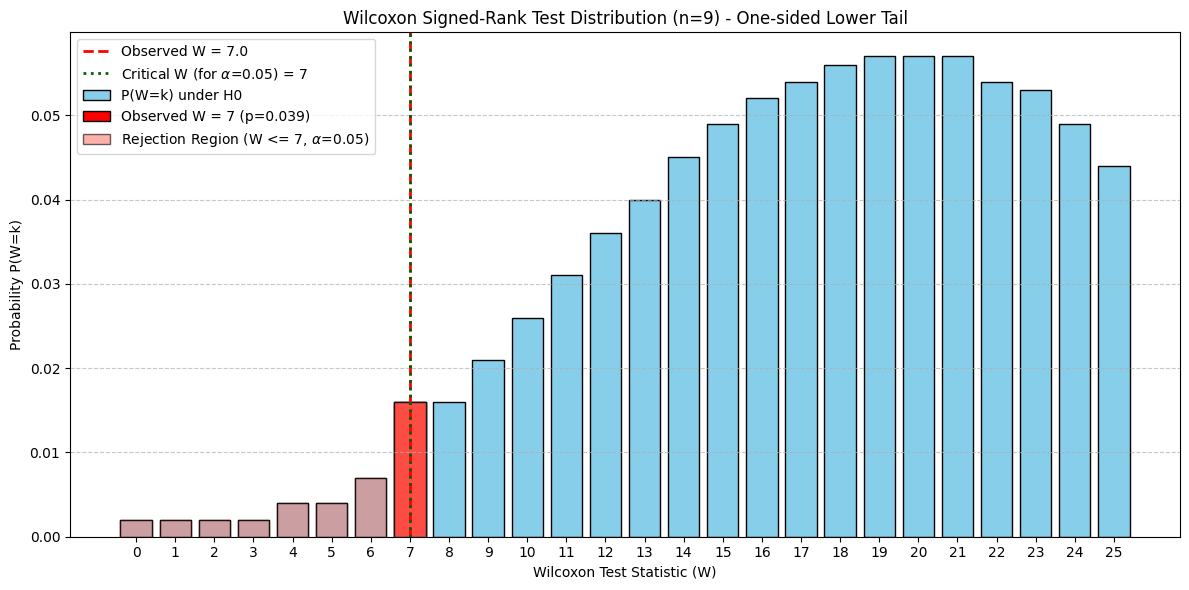

In [ ]:
# Define alpha
alpha = 0.05

# Reconstruct the PMF from the cumulative p-values (lookup table)
# This is a bit manual because the lookup table stores P(W <= k)
possible_W_values = sorted(wilcoxon_p_values_one_sided.keys())
cumulative_p_values = [wilcoxon_p_values_one_sided[w] for w in possible_W_values]

pmf_values = [cumulative_p_values[0]] # P(W=0)
for i in range(1, len(cumulative_p_values)):
    pmf_values.append(cumulative_p_values[i] - cumulative_p_values[i-1])

# Filter for relevant W values for plotting the lower tail (up to the point where p-value crosses alpha)
# We'll plot W values that contribute significantly to the lower tail.
plot_W_range_upper = 25 # Plot up to W=25, as it covers the rejection region well.
plot_W_values = [w for w in possible_W_values if w <= plot_W_range_upper]
plot_pmf_values = pmf_values[:len(plot_W_values)]

# Find the critical W value for alpha = 0.05
# The critical W value is the maximum value of W for which the cumulative p-value (under the null hypothesis)
# is less than or equal to our chosen significance level (alpha = 0.05).
critical_W_alpha = 0
for w_val, p_cum in wilcoxon_p_values_one_sided.items():
    if p_cum > alpha:
        break
    critical_W_alpha = w_val

# Create the plot
plt.figure(figsize=(12, 6))

# Plot PMF as bars
plt.bar(plot_W_values, plot_pmf_values, color='skyblue', label='P(W=k) under H0', edgecolor='black')

# Highlight observed W-statistic
plt.bar(observed_W_statistic, wilcoxon_p_values_one_sided.get(int(observed_W_statistic), 0) - wilcoxon_p_values_one_sided.get(int(observed_W_statistic)-1, 0),
        color='red', label=f'Observed W = {int(observed_W_statistic)} (p={p_value_lookup:.3f})', edgecolor='black')

# Highlight the rejection region
# Create a shaded area for rejection region (W <= critical_W_alpha)
reject_W_values = [w for w in plot_W_values if w <= critical_W_alpha]
reject_pmf_values = pmf_values[:len(reject_W_values)]
plt.bar(reject_W_values, reject_pmf_values, color='salmon', alpha=0.6, label=f'Rejection Region (W <= {critical_W_alpha}, $\\alpha$={alpha})', edgecolor='black')

plt.axvline(x=observed_W_statistic, color='red', linestyle='--', linewidth=2, label=f'Observed W = {observed_W_statistic}')
plt.axvline(x=critical_W_alpha, color='darkgreen', linestyle=':', linewidth=2, label=f'Critical W (for $\\alpha$={alpha}) = {critical_W_alpha}')

plt.title(f'Wilcoxon Signed-Rank Test Distribution (n={n_adjusted}) - One-sided Lower Tail')
plt.xlabel('Wilcoxon Test Statistic (W)')
plt.ylabel('Probability P(W=k)')
plt.xticks(plot_W_values)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()